In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv('weight-height.csv')


In [4]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

C:\Users\NB\AppData\Local\Temp\ipykernel_5692\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

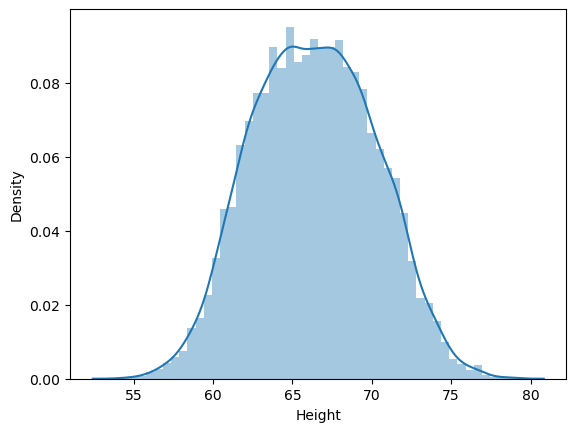

In [7]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

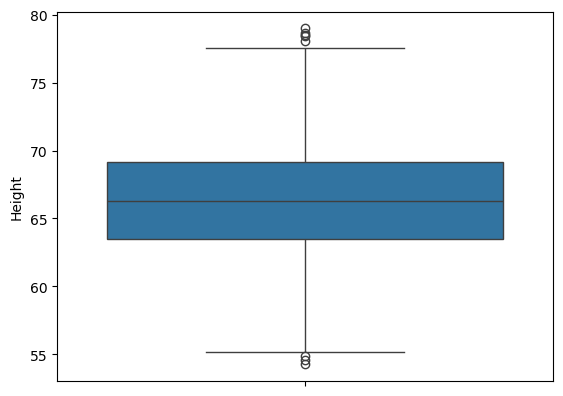

In [8]:
sns.boxplot(df['Height'])

In [9]:
# as we can clearly see there aresome outliers

In [10]:
# lets create upper and lower limit

In [11]:
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)

In [12]:
upper_limit

np.float64(74.7857900583366)

In [15]:
new_df = df[(df['Height'] < upper_limit) & (df['Height'] > lower_limit)]

In [17]:
new_df.shape

(9800, 3)

In [18]:
df.shape

(10000, 3)

In [19]:
# around 200 something rows were removed 

<Axes: ylabel='Height'>

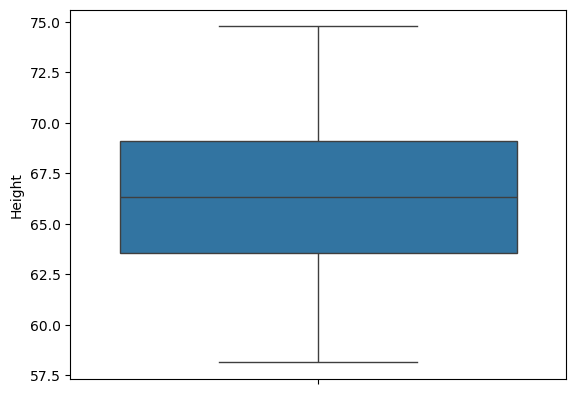

In [20]:
sns.boxplot(new_df['Height'])

In [21]:
# as you can see that all the outliers are removed 

C:\Users\NB\AppData\Local\Temp\ipykernel_5692\1622920233.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

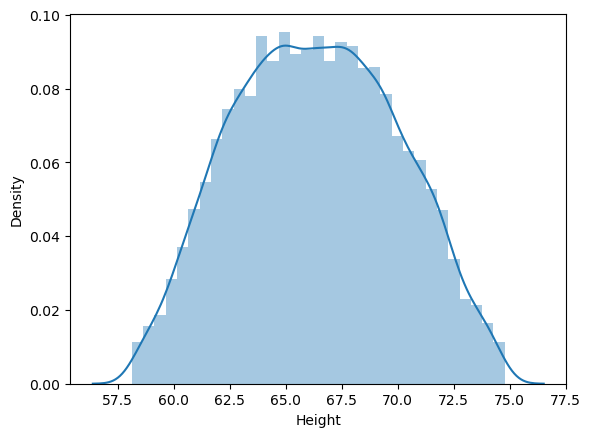

In [22]:
sns.distplot(new_df['Height'])

In [23]:
# the graph got a little thicker


## Cappint method aka Winsorization


In [27]:
df['Height'] = np.where(
    df['Height'] > upper_limit,
    upper_limit,
    np.where(
        df['Height'] < lower_limit,
        lower_limit,
        df['Height']
    )
)

C:\Users\NB\AppData\Local\Temp\ipykernel_5692\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

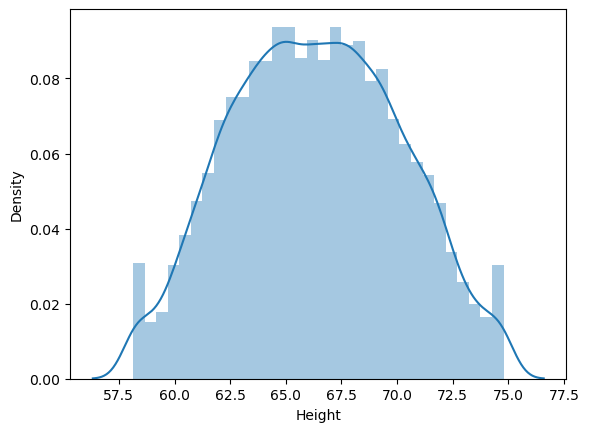

In [28]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

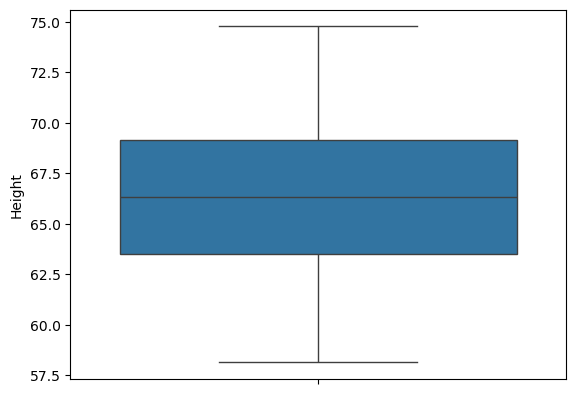

In [29]:
sns.boxplot(df['Height'])


# as you can clearly seee the outliers have been removed via tha capping methdd